# 2.1 — Full Odra: State Fidelity via Quantum State Tomography on IQM Spark

**Authors:** Koło Naukowe Axion

**Goal:** for each of the two ansatze, compute the **physically realised** state fidelity on the IQM Spark (Odra) quantum computer:

$$\mathcal{F} = \langle\psi_{\mathrm{ideal}}\,|\,\rho_{\mathrm{hardware}}\,|\,\psi_{\mathrm{ideal}}\rangle$$

where $\rho_{\mathrm{hardware}}$ is reconstructed from **real IQM Spark measurement counts** via **quantum state tomography**, not from a noise model.

Here we actually submit circuits to Odra, sweep measurement bases over the $3^n$ tensor-product Pauli bases, and reconstruct $\rho$ from the bitstring counts.

**Workflow**
1. Prepare each ansatz/circuit on IQM Spark with trained weights.
2. Repeat the experiment in all $3^n$ tensor-product measurement bases.
3. Reconstruct the experimental density matrix $\rho_{\mathrm{hardware}}$ via the Pauli expansion.
4. Simulate the same circuit ideally to get $|\psi_{\mathrm{ideal}}\rangle$.
5. Compute $\mathcal{F} = \langle\psi|\rho|\psi\rangle$ per ansatz / per input.

For $n=5$ qubits this is $3^5 = 243$ measurement settings per input. We therefore default to a **small** test subsample so the IQM Spark queue time stays manageable; the number of inputs is controlled by `N_TOMOGRAPHY_INPUTS`.

## 1. Imports & Reproducibility

In [ ]:
import time

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from iqm.qiskit_iqm import IQMProvider

from qbanknote.paths import ensure_importable
ensure_importable()

from qbanknote.ansatzes import (
    ansatz_trimmed_reverse_q0_param_count,
    simulator_ansatz as ansatz,
    odra_ansatz as ansatz_Odra,
)
from qbanknote.data import set_random_seed, load_fold_arrays
from qbanknote.model import angle_encoding_feature_map
from qbanknote.weights import load_trained_weights, metric_weight_path
from qbanknote.tomography import (
    all_basis_settings,
    add_tomography_rotations,
    expectation_from_counts,
    reconstruct_rho,
    project_to_physical,
    state_fidelity_pure,
    build_bound_circuit,
    run_tomography_jobs,
)

RANDOM_SEED = 42
set_random_seed(RANDOM_SEED)

# --- Experiment configuration (kept in sync with scripts/pilot_state_fidelity.py) ---
NUM_QUBITS = 5
ANSATZ_DEPTH = 2          # depth of the trained ansatz / checkpoints
FOLD = 1                  # cross-validation fold to evaluate (1..5)
CHECKPOINT_EPOCH = 30     # trained-weights epoch (see iqm_metric_test_config.toml)


## 2. Ansatz Definitions



- **Ansatz 1 — Ring (simulator-optimized).** RY · CRX · RX · CRY ring with a q0-incident reverse trim on the last macro-layer.
- **Ansatz 2 — Odra (IQM-Spark adapted).** A hardware-efficient variant using gates that decompose cheaply to IQM Spark's native `r` / `cz` basis.

In [48]:
# Ansatz definitions imported from qbanknote.ansatzes (see setup cell).


## 3. Test Data & Trained Weights (per cross-validation fold)

We evaluate one CV fold at a time (`FOLD`). The test inputs come from that fold's
`test_data.csv`, and the trained weights are the matching `depth=ANSATZ_DEPTH`,
`epoch=CHECKPOINT_EPOCH` checkpoints from `cross_validation/Models/Weights/`.

This is exactly the configuration `scripts/pilot_state_fidelity.py` uses, so the
shot count / number of inputs it recommends apply directly here. To evaluate a
different fold, change `FOLD` in the setup cell and re-run.



In [49]:
# Per-fold test split — same data the trained checkpoints were validated on,
# and the same split scripts/pilot_state_fidelity.py uses to pick shots / n_samples.
# load_fold_arrays returns features already scaled to [-pi/4, pi/4] and labels in {-1, 1}.
X_test, y_test = load_fold_arrays(FOLD, split="test")
X_test_np = X_test.astype(np.float32)
y_test = y_test.astype(np.float32)

# Convenience: original {0, 1} labels for printing.
y_test_raw = ((y_test + 1) / 2).astype(int)

print(f"Loaded {len(X_test_np)} test samples for fold {FOLD} (n_features={X_test_np.shape[1]})")

Loaded 275 test samples for fold 1 (n_features=5)


In [50]:
# Load the trained checkpoints for this fold from the cross-validation weights tree
# (qbanknote.weights.metric_weight_path resolves the canonical filenames).
original_circuit = ansatz(NUM_QUBITS, ANSATZ_DEPTH)
odra_circuit = ansatz_Odra(NUM_QUBITS, ANSATZ_DEPTH)

simulator_weight_path = metric_weight_path(
    ANSATZ_DEPTH, "simulator", FOLD, epoch=CHECKPOINT_EPOCH
)
odra_weight_path = metric_weight_path(
    ANSATZ_DEPTH, "odra", FOLD, epoch=CHECKPOINT_EPOCH
)

original_weights = load_trained_weights(simulator_weight_path, original_circuit)
odra_weights = load_trained_weights(odra_weight_path, odra_circuit)

print(f"Simulator weights: {simulator_weight_path.name}")
print(f"Odra weights:      {odra_weight_path.name}")
print(
    f"Loaded {original_weights.size} trained weights for Original (Ring) ansatz; "
    f"first 3 = {original_weights[:3].round(4).tolist()}"
)
print(
    f"Loaded {odra_weights.size} trained weights for Odra ansatz; "
    f"first 3 = {odra_weights[:3].round(4).tolist()}"
)

Simulator weights: Simulator_fold_1_depth_4_epoch_30_weights.pth
Odra weights:      Odra_fold_1_depth_4_epoch_30_weights.pth
Loaded 37 trained weights for Original (Ring) ansatz; first 3 = [1.223, 0.901, 0.35]
Loaded 37 trained weights for Odra ansatz; first 3 = [0.4051, 0.8838, -0.0432]


## 4. Tomography Circuits

For each Pauli basis $b \in \{X, Y, Z\}^n$ we apply a per-qubit rotation that maps the chosen Pauli eigenbasis to the computational basis, then measure:

| basis | rotation |
| --- | --- |
| $Z$ | identity |
| $X$ | $H$ |
| $Y$ | $S^{\dagger}\,H$ |

The result is one circuit per basis tuple. For 5 qubits that's $3^5 = 243$ circuits per (ansatz, input) pair.

In [51]:
# build_bound_circuit, add_tomography_rotations, all_basis_settings from qbanknote.tomography
basis_settings = all_basis_settings(NUM_QUBITS)
print(f"Number of basis settings for n={NUM_QUBITS}: {len(basis_settings)} (= 3^{NUM_QUBITS})")

Number of basis settings for n=5: 243 (= 3^5)


## 5. Connect to IQM Spark

Same connection pattern as section 7 of `2_1_ansatz_comparison_error_gate.ipynb` — re-enter your IQM token and let `qiskit-iqm` resolve `iqm_backend`.

In [52]:
try:
    provider = IQMProvider("https://odra5.e-science.pl/", token=input("Enter IQM Token: "))
    iqm_backend = provider.get_backend()
    print(f"Connected to backend: {iqm_backend.name}  (n_qubits = {iqm_backend.num_qubits})")
except Exception as e:
    print(f"Connection error: {e}")
    raise

Connected to backend: IQMBackend  (n_qubits = 5)


## 6. Submitting Tomography Jobs to IQM Spark

We transpile every tomography circuit to IQM Spark's native gate set (this turns the `H` / `S^dagger` rotations into `r` / `cz` sequences automatically) and submit them to the backend in batches.

Knobs:
- `SHOTS_PER_BASIS` — number of shots per (ansatz, input, basis) circuit. **Set this to the `chosen_shots` value reported by `scripts/pilot_state_fidelity.py`** (read it from `…/iqm_fidelity_outputs/pilots/<pilot_id>/fidelity_protocol_recommendation.json`).
- `MAX_CIRCUITS_PER_JOB` — how many circuits to bundle into a single IQM job.

For `n=5` we have 243 bases × `SHOTS_PER_BASIS` shots × `N_TOMOGRAPHY_INPUTS` inputs × 2 ansatze.

In [53]:
SHOTS_PER_BASIS = 1024  # pilot chosen_shots (scripts/pilot_state_fidelity.py; same for depths 2/4/6)
MAX_CIRCUITS_PER_JOB = 250


def run_tomography_jobs(
    state_circuit: QuantumCircuit,
    backend,
    shots: int = SHOTS_PER_BASIS,
    max_circuits_per_job: int = MAX_CIRCUITS_PER_JOB,
    label: str = "",
) -> dict[tuple, dict]:
    """Run all 3^n tomography circuits for ``state_circuit`` on ``backend``.

    Returns
    -------
    dict
        ``{(basis_tuple): {bitstring: count, ...}}`` for every basis in
        ``all_basis_settings(NUM_QUBITS)``.
    """
    bases = all_basis_settings(NUM_QUBITS)
    tomo_circuits = [add_tomography_rotations(state_circuit, b) for b in bases]

    transpiled = transpile(tomo_circuits, backend=backend, optimization_level=1)

    print(
        f"  [{label}] submitting {len(transpiled)} tomography circuits "
        f"in batches of {max_circuits_per_job} ({shots} shots each)..."
    )

    counts_per_basis: dict[tuple, dict] = {}

    submitted = 0
    while submitted < len(transpiled):
        batch = transpiled[submitted: submitted + max_circuits_per_job]
        batch_bases = bases[submitted: submitted + max_circuits_per_job]

        t0 = time.perf_counter()
        job = backend.run(batch, shots=shots)
        result = job.result()
        dt = time.perf_counter() - t0

        for j, basis_tuple in enumerate(batch_bases):
            counts_per_basis[basis_tuple] = result.get_counts(j)

        submitted += len(batch)
        print(
            f"    batch done: {submitted:>4}/{len(transpiled)}  "
            f"({dt:.1f}s on the backend)"
        )

    return counts_per_basis

## 7. Pauli Expectation Values & Density Matrix Reconstruction

Given measurement counts in a particular basis, the expectation value of any compatible Pauli string $P$ (whose non-identity positions agree with the measurement basis) is

$$\langle P\rangle = \sum_{\text{bitstring } b} \frac{n_b}{N_{\text{shots}}} \prod_{i : P_i \neq I} (-1)^{b_i}.$$

The density matrix is then reconstructed via the Pauli expansion

$$\rho = \frac{1}{2^n}\sum_{P\in\{I,X,Y,Z\}^{\otimes n}} \langle P\rangle\,P,$$

a linear inversion that can yield small negative eigenvalues from shot noise — we therefore project the result onto the positive-semidefinite cone with trace 1 after reconstruction (helpful for the fidelity formula).

In [54]:
# Tomography reconstruction helpers imported from qbanknote.tomography


## 8. Full Tomography Pipeline (per input × per ansatz)

The function below ties everything together for a single (ansatz, input) pair:

1. Compose the prepared-state circuit (feature map + ansatz, with `x` and `θ*` already bound).
2. Compute the ideal pure state $|\psi_{\mathrm{ideal}}\rangle$ from the noiseless statevector.
3. Run all $3^n$ tomography circuits on IQM Spark and collect bitstring counts.
4. Reconstruct $\rho_{\mathrm{hardware}}$ via linear inversion and project to a physical state.
5. Compute $\mathcal{F} = \langle\psi_{\mathrm{ideal}}|\rho_{\mathrm{hardware}}|\psi_{\mathrm{ideal}}\rangle$.

In [55]:
def tomography_fidelity_one(
    ansatz_circuit: QuantumCircuit,
    weight_values: np.ndarray,
    x_value: np.ndarray,
    backend,
    label: str = "",
) -> dict:
    """Run the full hardware-tomography fidelity protocol for one input."""
    bound = build_bound_circuit(
        ansatz_circuit, x_value=x_value, weight_values=weight_values, n_qubits=NUM_QUBITS
    )

    psi_ideal = Statevector.from_instruction(bound).data

    tomo_counts = run_tomography_jobs(bound, backend, label=label)

    rho_lin = reconstruct_rho(tomo_counts, n_qubits=NUM_QUBITS)
    rho_phys = project_to_physical(rho_lin)

    F_lin = state_fidelity_pure(psi_ideal, rho_lin)
    F_phys = state_fidelity_pure(psi_ideal, rho_phys)

    purity_lin = float(np.real(np.trace(rho_lin @ rho_lin)))
    purity_phys = float(np.real(np.trace(rho_phys @ rho_phys)))
    trace_lin = float(np.real(np.trace(rho_lin)))
    trace_phys = float(np.real(np.trace(rho_phys)))

    return {
        "fidelity_linear_inversion": F_lin,
        "fidelity_physical_projection": F_phys,
        "trace_linear": trace_lin,
        "trace_physical": trace_phys,
        "purity_linear": purity_lin,
        "purity_physical": purity_phys,
        "rho_physical": rho_phys,
        "psi_ideal": psi_ideal,
    }

## 9. Sweep Both Ansatze on a Few Test Inputs

This is the hardware-heavy cell. The constants control how many IQM Spark jobs you commit to:

- `N_TOMOGRAPHY_INPUTS` — number of test inputs we run tomography on **per ansatz**.
- Total circuits = `N_TOMOGRAPHY_INPUTS × 243 × 2`.
- Total shots   = total circuits × `SHOTS_PER_BASIS`.

Default (pilot-calibrated): **10 inputs per ansatz**, i.e. `10 × 243 × 2 = 4860` circuits × `1024` shots = `4,976,640` total shots on IQM Spark.

In [56]:
N_TOMOGRAPHY_INPUTS = 10  # pilot chosen_n_samples (scripts/pilot_state_fidelity.py; same for depths 2/4/6)

inputs_to_test = X_test_np[:N_TOMOGRAPHY_INPUTS]

results = {
    "Original (Ring, sim-opt)":   {"circuit": original_circuit, "weights": original_weights, "per_input": []},
    "Odra (IQM-Spark adapted)":   {"circuit": odra_circuit,     "weights": odra_weights,     "per_input": []},
}

t_start = time.perf_counter()
for label, blob in results.items():
    print(f"\n=== Tomography sweep for {label} ===")
    for i, x_val in enumerate(inputs_to_test):
        print(f"\n  input #{i+1}/{len(inputs_to_test)} (fold {FOLD} test index {i}, label y={int(y_test_raw[i])})")
        out = tomography_fidelity_one(
            ansatz_circuit=blob["circuit"],
            weight_values=blob["weights"],
            x_value=x_val,
            backend=iqm_backend,
            label=label,
        )
        out["fold"] = int(FOLD)
        out["fold_test_index"] = int(i)
        out["y_true"] = int(y_test_raw[i])
        blob["per_input"].append(out)

        print(
            f"    F (linear inv.)        = {out['fidelity_linear_inversion']:.4f}\n"
            f"    F (physical proj.)     = {out['fidelity_physical_projection']:.4f}\n"
            f"    trace rho (lin / phys) = {out['trace_linear']:.4f} / {out['trace_physical']:.4f}\n"
            f"    purity (lin / phys)    = {out['purity_linear']:.4f} / {out['purity_physical']:.4f}"
        )

print(f"\nTotal wall time: {(time.perf_counter() - t_start)/60:.1f} min")


=== Tomography sweep for Original (Ring, sim-opt) ===

  input #1/10 (fold 1 test index 0, label y=0)
  [Original (Ring, sim-opt)] submitting 243 tomography circuits in batches of 250 (1024 shots each)...
    batch done:  243/243  (115.0s on the backend)
    F (linear inv.)        = 0.2761
    F (physical proj.)     = 0.2665
    trace rho (lin / phys) = 1.0000 / 1.0000
    purity (lin / phys)    = 0.1667 / 0.1377

  input #2/10 (fold 1 test index 1, label y=0)
  [Original (Ring, sim-opt)] submitting 243 tomography circuits in batches of 250 (1024 shots each)...
    batch done:  243/243  (149.7s on the backend)
    F (linear inv.)        = 0.3305
    F (physical proj.)     = 0.3185
    trace rho (lin / phys) = 1.0000 / 1.0000
    purity (lin / phys)    = 0.2201 / 0.1812

  input #3/10 (fold 1 test index 2, label y=0)
  [Original (Ring, sim-opt)] submitting 243 tomography circuits in batches of 250 (1024 shots each)...
    batch done:  243/243  (150.2s on the backend)
    F (linear inv.

## 10. Comparison Report

We report two fidelity numbers per ansatz:

- **`fidelity_linear_inversion`** — the raw $\langle\psi|\rho|\psi\rangle$ from the linear-inversion $\rho$. This can be slightly above 1 (or below 0) for any individual sample because shot noise produces non-physical eigenvalues; it stays useful as a *mean* over inputs.
- **`fidelity_physical_projection`** — the same formula but after projecting $\rho$ onto the positive-semidefinite, trace-1 cone. This is the "publication" number.

The histogram below compares the per-input projected fidelities of the two ansatze.

Ansatz                             n   F lin mean    F lin std   F phys mean   F phys std      min      max
------------------------------------------------------------------------------------------
Original (Ring, sim-opt)          10       0.2662       0.0273        0.2561       0.0264   0.2288   0.3185
Odra (IQM-Spark adapted)          10       0.3447       0.0293        0.3328       0.0284   0.3010   0.3881


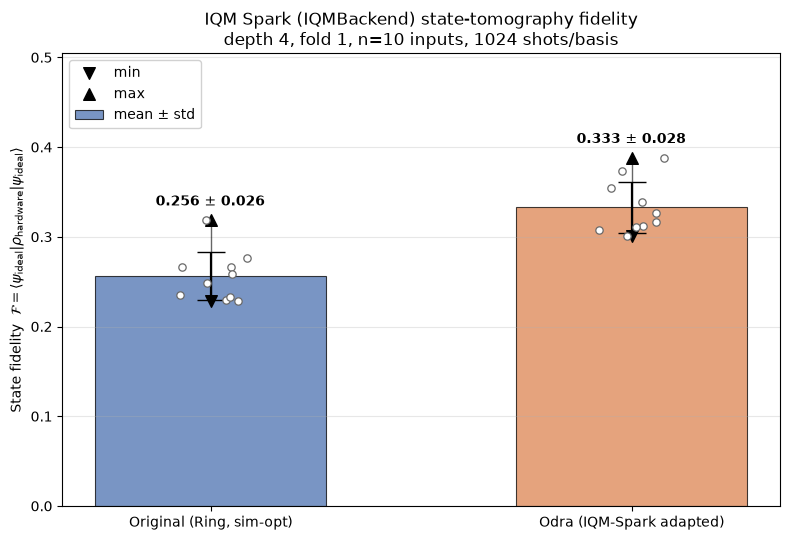

In [57]:
def summarise(blob: dict) -> dict:
    Fs_lin = np.array([r["fidelity_linear_inversion"]   for r in blob["per_input"]])
    Fs_phy = np.array([r["fidelity_physical_projection"] for r in blob["per_input"]])
    return {
        "n_inputs":      len(Fs_lin),
        "F_lin_mean":    float(Fs_lin.mean()),
        "F_lin_std":     float(Fs_lin.std(ddof=0)),
        "F_phys_mean":   float(Fs_phy.mean()),
        "F_phys_std":    float(Fs_phy.std(ddof=0)),
        "F_phys_min":    float(Fs_phy.min()),
        "F_phys_max":    float(Fs_phy.max()),
        "Fs_phys":       Fs_phy,
    }


print("=" * 90)
print(
    f"{'Ansatz':<32}{'n':>4}"
    f"{'F lin mean':>13}{'F lin std':>13}"
    f"{'F phys mean':>14}{'F phys std':>13}{'min':>9}{'max':>9}"
)
print("-" * 90)

summaries = {}
for label, blob in results.items():
    s = summarise(blob)
    summaries[label] = s
    print(
        f"{label:<32}{s['n_inputs']:>4}"
        f"{s['F_lin_mean']:>13.4f}{s['F_lin_std']:>13.4f}"
        f"{s['F_phys_mean']:>14.4f}{s['F_phys_std']:>13.4f}"
        f"{s['F_phys_min']:>9.4f}{s['F_phys_max']:>9.4f}"
    )
print("=" * 90)

ring_label = next((l for l in summaries if "Ring" in l or "sim" in l.lower()), None)
odra_label = next((l for l in summaries if "Odra" in l or "hw" in l.lower()), None)
if ring_label and odra_label:
    gap_mean = summaries[odra_label]["F_phys_mean"] - summaries[ring_label]["F_phys_mean"]
    print(f"\nFidelity gap (Odra − Ring): {gap_mean:+.4f}")
    print(f"  Odra  mean F_phys = {summaries[odra_label]['F_phys_mean']:.4f}")
    print(f"  Ring  mean F_phys = {summaries[ring_label]['F_phys_mean']:.4f}")


# Clear summary plot: mean +/- std bar, with min/max whiskers and the
# individual per-input fidelities overlaid (one point per test input).
labels_list = list(summaries.keys())
means = np.array([summaries[l]["F_phys_mean"] for l in labels_list])
stds = np.array([summaries[l]["F_phys_std"] for l in labels_list])
mins = np.array([summaries[l]["F_phys_min"] for l in labels_list])
maxs = np.array([summaries[l]["F_phys_max"] for l in labels_list])
x = np.arange(len(labels_list))
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))

# mean bar with +/- std error bars
ax.bar(
    x, means, yerr=stds, width=0.55, capsize=10,
    color=[colors[i % len(colors)] for i in range(len(x))],
    alpha=0.75, edgecolor="black", linewidth=0.8,
    error_kw={"elinewidth": 1.6, "ecolor": "black"},
    label="mean $\\pm$ std",
)

# min / max markers and a thin range line connecting them
ax.vlines(x, mins, maxs, color="black", linewidth=1.0, alpha=0.6)
ax.scatter(x, mins, marker="v", s=70, color="black", zorder=4, label="min")
ax.scatter(x, maxs, marker="^", s=70, color="black", zorder=4, label="max")

# individual per-input fidelities (slight horizontal jitter so they don't overlap)
rng = np.random.default_rng(RANDOM_SEED)
for xi, l in zip(x, labels_list):
    pts = summaries[l]["Fs_phys"]
    jitter = (rng.random(len(pts)) - 0.5) * 0.18
    ax.scatter(
        np.full(len(pts), xi) + jitter, pts,
        s=28, color="white", edgecolor="dimgray", linewidth=0.9, zorder=5,
    )

# annotate mean +/- std above each bar
for xi, m, sd, mx in zip(x, means, stds, maxs):
    ax.text(
        xi, max(m + sd, mx) + 0.012, f"{m:.3f} $\\pm$ {sd:.3f}",
        ha="center", va="bottom", fontsize=10, fontweight="bold",
    )

ax.set_xticks(x)
ax.set_xticklabels(labels_list)
ax.set_ylabel(
    r"State fidelity  $\mathcal{F} = \langle\psi_{\mathrm{ideal}}|\rho_{\mathrm{hardware}}|\psi_{\mathrm{ideal}}\rangle$"
)
ax.set_ylim(0, float(maxs.max()) * 1.3)
ax.set_title(
    f"IQM Spark ({iqm_backend.name}) state-tomography fidelity\n"
    f"depth {ANSATZ_DEPTH}, fold {FOLD}, n={summaries[labels_list[0]]['n_inputs']} inputs, "
    f"{SHOTS_PER_BASIS} shots/basis"
)
ax.legend(loc="upper left", framealpha=0.9)
ax.grid(True, axis="y", alpha=0.3)

if ring_label and odra_label:
    ax.text(
        0.98, 0.04,
        f"Odra − Ring gap: {gap_mean:+.3f}",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="gray", alpha=0.9),
    )

plt.tight_layout()
plt.show()